#1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
import shap
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from xgboost import XGBClassifier, plot_importance

# **All directories are based on google colab's file structure.**

#2. Load Data

In [2]:
!git clone https://github.com/jfung07/UCLA_Thesis
base = "/content/UCLA_Thesis/data"

Cloning into 'UCLA_Thesis'...
remote: Enumerating objects: 1800, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 1800 (delta 24), reused 78 (delta 16), pack-reused 1711 (from 1)
Receiving objects: 100% (1800/1800), 929.68 MiB | 25.24 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (1690/1690), done.


In [3]:
df = pd.read_excel(os.path.join(base, "processed.xlsx"))

split_path = os.path.join(base, "split")
train_df = pd.read_excel(os.path.join(split_path, "train.xlsx"))
val_df = pd.read_excel(os.path.join(split_path, "val.xlsx"))
test_df = pd.read_excel(os.path.join(split_path, "test.xlsx"))

## 2a. Convert Categorical Variables

In [4]:
cat_col = ['game', 'set_loc', 'set_receiver', 'team']
for data in [df, train_df, val_df, test_df]:
  for col in cat_col:
    data[col] = data[col].astype(str).str.strip().astype('category')


# 3. Set Loc

## 3a. Data and Transforms

In [5]:
X_train_loc = train_df.drop(columns=['observation', 'receiver_loc', 'pass_loc', 'set_loc', 'num_block', 'set_receiver', 'kill', 'game_sex', 'level'])
loc_train = train_df['set_loc']
loc_train = loc_train.reset_index(drop=True)
X_val_loc = val_df.drop(columns=['observation', 'receiver_loc', 'pass_loc', 'set_loc', 'num_block', 'set_receiver', 'kill', 'game_sex', 'level'])
loc_val = val_df['set_loc']
loc_val   = loc_val.reset_index(drop=True)
X_test_loc = test_df.drop(columns=['observation', 'receiver_loc', 'pass_loc', 'set_loc', 'num_block', 'set_receiver', 'kill', 'game_sex', 'level'])
loc_test = test_df['set_loc']
loc_test  = loc_test.reset_index(drop=True)
classes = df['set_loc'].value_counts().index.tolist()
NUM_CLASS = len(df['set_loc'].value_counts().index.tolist())

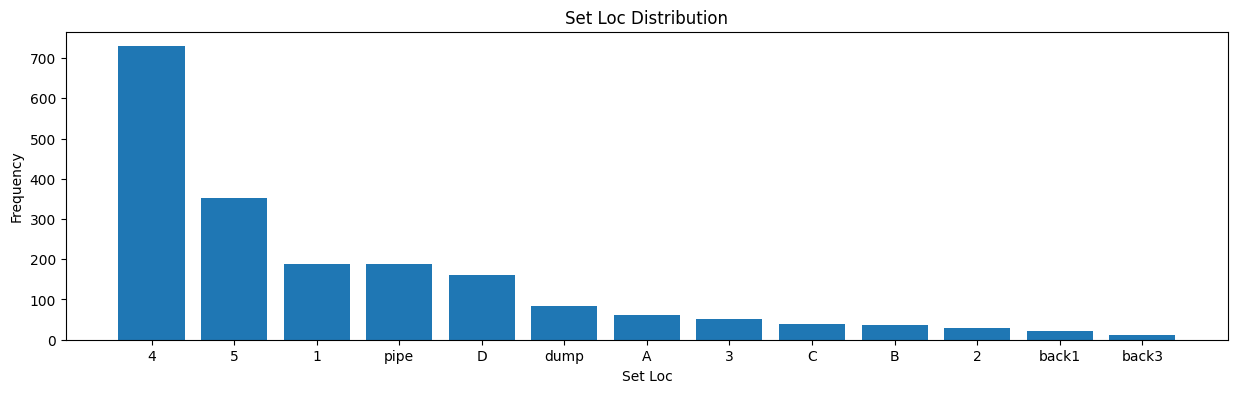

In [6]:
nums = df['set_loc'].value_counts()
fig, ax = plt.subplots(figsize = (15,4))
ax.bar(nums.index.astype(str), nums.values)
ax.set_xlabel("Set Loc")
ax.set_ylabel("Frequency")
ax.set_title("Set Loc Distribution")
plt.show()

##3b. Configurations

In [7]:
experiments = [
    # 0: baseline
    {'objective': 'multi:softprob', 'num_class': NUM_CLASS, 'max_depth': 4,
     'learning_rate': 0.1, 'n_estimators': 300, 'alpha': 1},
    # 1: smaller learning rate/more trees - better generalization
    {'objective': 'multi:softprob', 'num_class': NUM_CLASS, 'max_depth': 4,
     'learning_rate': 0.05, 'n_estimators': 400, 'alpha': 1},
    # 2: larger learning rate/less trees - unstable learning
    {'objective': 'multi:softprob', 'num_class': NUM_CLASS, 'max_depth': 3,
     'learning_rate': 0.2, 'n_estimators': 80, 'alpha': 1},
    # 3: smaller alpha/deeper - more flexible
    {'objective': 'multi:softprob', 'num_class': NUM_CLASS, 'max_depth': 4,
     'learning_rate': 0.1, 'n_estimators': 300, 'alpha': 0.5},
    # 4: larger alpha - prevent overfitting
    {'objective': 'multi:softprob', 'num_class': NUM_CLASS, 'max_depth': 5,
     'learning_rate': 0.1, 'n_estimators': 300, 'alpha': 5},
]

## 3c. Encoder

In [8]:
le = LabelEncoder()
le.fit(loc_train)
loc_train_enc = le.transform(loc_train)
loc_val_enc = le.transform(loc_val)
loc_test_enc = le.transform(loc_test)

##3d. Performance

In [9]:
DETERMINISTIC_ARGS = dict(
    enable_categorical=True,
    random_state=256,
    tree_method="hist",        # for repoduce
    n_jobs=1,                   # for reproduce
    sampling_method="uniform"   # for reproduce
)

In [10]:
loc_results = []
best_model = None
best_f1 = -1
print(f"Starting Grid Search on {len(experiments)} configurations...\n")
for i, conf in enumerate(experiments):
  model = XGBClassifier(**DETERMINISTIC_ARGS, **conf)
  model.fit(X_train_loc, loc_train_enc)
  y_pred = model.predict(X_val_loc)
  acc = accuracy_score(loc_val_enc, y_pred)
  f1 = f1_score(loc_val_enc, y_pred, average = "macro")
  res = conf.copy()
  res['index'] = i
  res['accuracy'] = acc
  res['f1'] = f1
  loc_results.append(res)
  print(f"Exp {i+1}:  LR = {conf['learning_rate']},  alpha = {conf['alpha']} ->  Val acc: {acc:.4f}, Val F1: {f1:.3f}")
  if f1 > best_f1:
    best_f1 = f1
    best_model = model

df_loc_results = pd.DataFrame(loc_results)
print("\n" + "="*40)
print(" Final Leaderboard by F1")
print("="*40)
# sort best to worst
print(df_loc_results.sort_values(by="f1", ascending = False).to_string(index=False))



Starting Grid Search on 5 configurations...

Exp 1:  LR = 0.1,  alpha = 1 ->  Val acc: 0.3276, Val F1: 0.140
Exp 2:  LR = 0.05,  alpha = 1 ->  Val acc: 0.3208, Val F1: 0.129
Exp 3:  LR = 0.2,  alpha = 1 ->  Val acc: 0.3515, Val F1: 0.127
Exp 4:  LR = 0.1,  alpha = 0.5 ->  Val acc: 0.3106, Val F1: 0.123
Exp 5:  LR = 0.1,  alpha = 5 ->  Val acc: 0.3584, Val F1: 0.112

 Final Leaderboard by F1
     objective  num_class  max_depth  learning_rate  n_estimators  alpha  index  accuracy       f1
multi:softprob         13          4           0.10           300    1.0      0  0.327645 0.139749
multi:softprob         13          4           0.05           400    1.0      1  0.320819 0.129364
multi:softprob         13          3           0.20            80    1.0      2  0.351536 0.126964
multi:softprob         13          4           0.10           300    0.5      3  0.310580 0.122552
multi:softprob         13          5           0.10           300    5.0      4  0.358362 0.112422


The baseline model performs the best with a 32.765% accuracy and F1 of 0.1397.  The small learning rate follows closely with a slightly lower accuracy and a f1 score. The large alpha model has the best accuracy, but the worst f1.

##3e. Performance on Test Set

###3e2. Importance Plots

#### Accuracy Gain

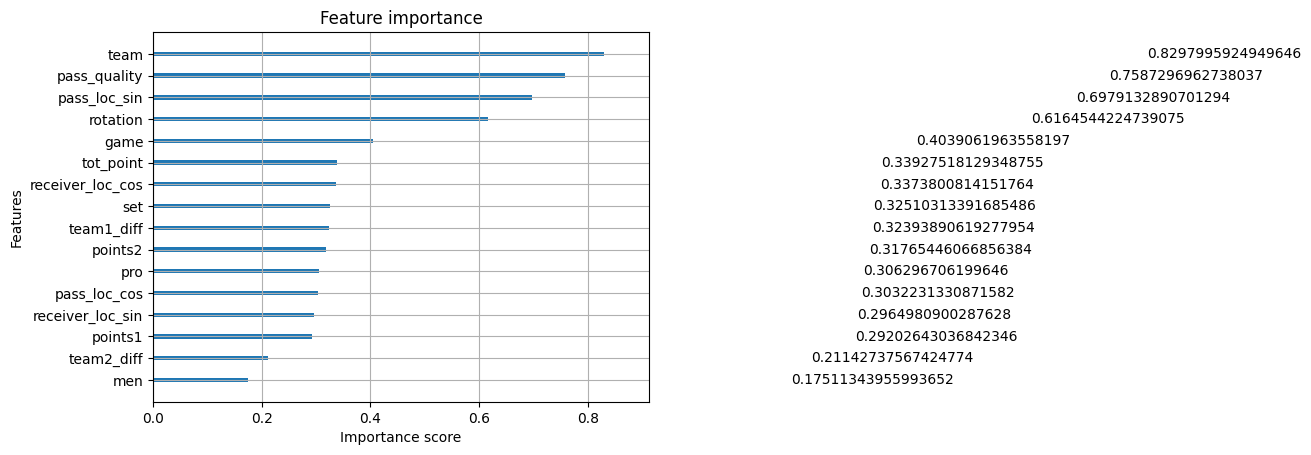

In [11]:
plot_importance(best_model, importance_type = 'gain')
plt.show()

Team inproves accuracy the most followed by pass_quality and second touch net distance then rotation.  The least important are gender and points.  Many variables account for similar variability, so might investigate simpler model.

#### Weight Importance

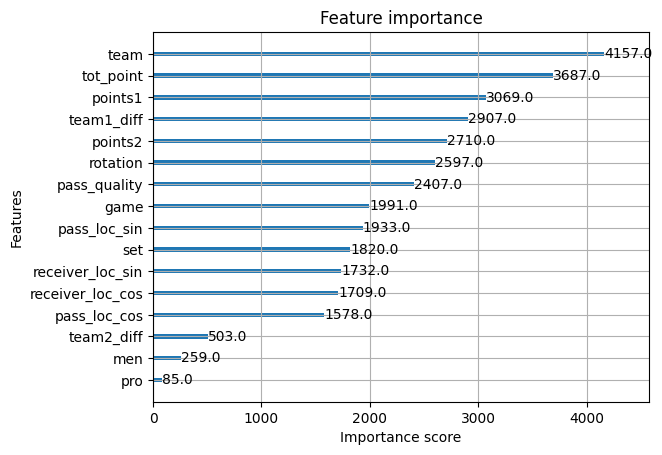

In [12]:
plot_importance(best_model, importance_type = 'weight')
plt.show()

The model uses team, and the point features to split the most frequently as well as rotation and pass_quality.  On the other hand level, gender, and receiver location are the least important.

The plots indicate that one point variable maybe sufficient, and level and gender may have negligiable effects.  Investigate a simpler model with total points, pass quality, pass_loc_sin, team, and rotation as the features tend to appear in the top half of each importance plot.  Similarly, many features have overlapping characteristics, so might investigate a model with total points(rep point features), pass_quality(representing first and second touch), team(rep game unique), set(game stage)

#### Shap Values

In [13]:
#del shap_values

explainer = shap.Explainer(best_model)
sv = explainer(X_test_loc)

print("sv shape:", sv.values.shape)
print("X_train_loc shape:", X_test_loc.shape)

sv shape: (293, 16, 13)
X_train_loc shape: (293, 16)


In [14]:
print(le.classes_)

['1' '2' '3' '4' '5' 'A' 'B' 'C' 'D' 'back1' 'back3' 'dump' 'pipe']


Location 1

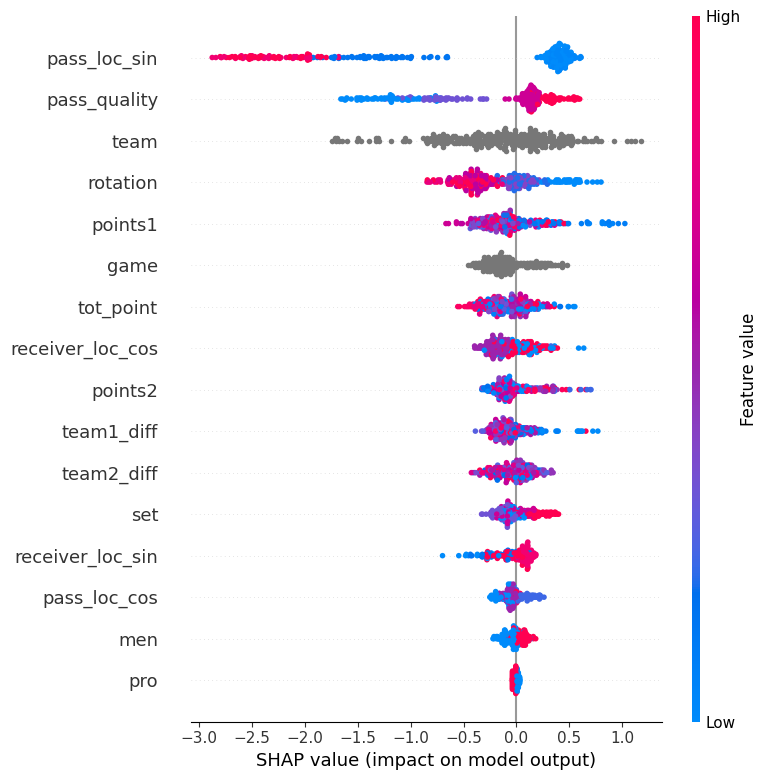

In [15]:
sv_class0 = sv.values[:, :, 0]   # shape (1366, 16)
shap.summary_plot(sv_class0, X_test_loc)


how far the second touch occurs from the net and the quality of the first touch are the most important predictors for a 1 set followed by the team and rotation.  The least significant predictors are level, gender, set number, and lateral location of the second touch after accounting for all other variables with low magnitude SHAP values.  Directionally, second touches closer to the net are more likely to be 1 sets; similarly, as the pass quality increases, the set is more likely to be a 1.  When the setter is in the back row, the set is more likely to be a 1 location.  Men tend to set a 1 location more than women. In the beginning of a set(points1 inc) the set is more likely to be a 1, conversely, as the game progresses(set inc) the set is more likely to be a 1, but the association is weaker.  Additionally, the closer the first touch occurs relative to the net, the set is less likely to be a 1 location.   

Location 2

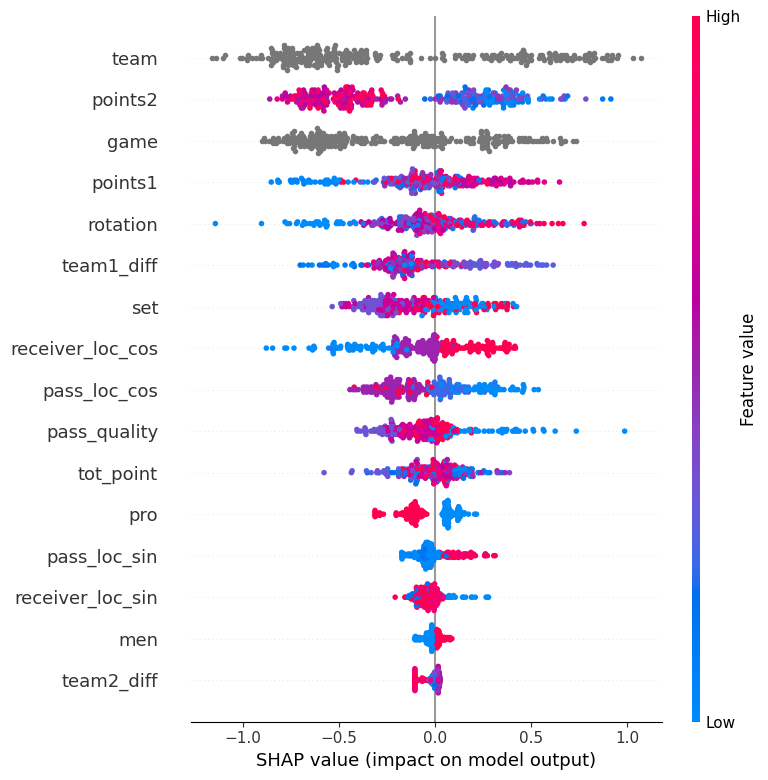

In [16]:
sv_class1 = sv.values[:, :, 1]   # shape (1366, 16)
shap.summary_plot(sv_class1, X_test_loc)

Team, game and points for each team are the most important.  When the setter is in the back, a 2 is less likely than in the front.  When the receiver is on the right side rather than the left, the set is less likely to be a 2.  When the setter is on the right, the set is more likely to be a 2 compared to the left.  When the pass is low quality, the set is more likely to be a 2 than when the pass is good.  Professionals tend to set 2s less than d1 players.  The when the first touch is close to the net, the set is more likely to be a 2 than when the first touch is far.  When the second touch is far from the net, a two is more likely than when it is close.  Men tend to set 2s more than women.  

3 location

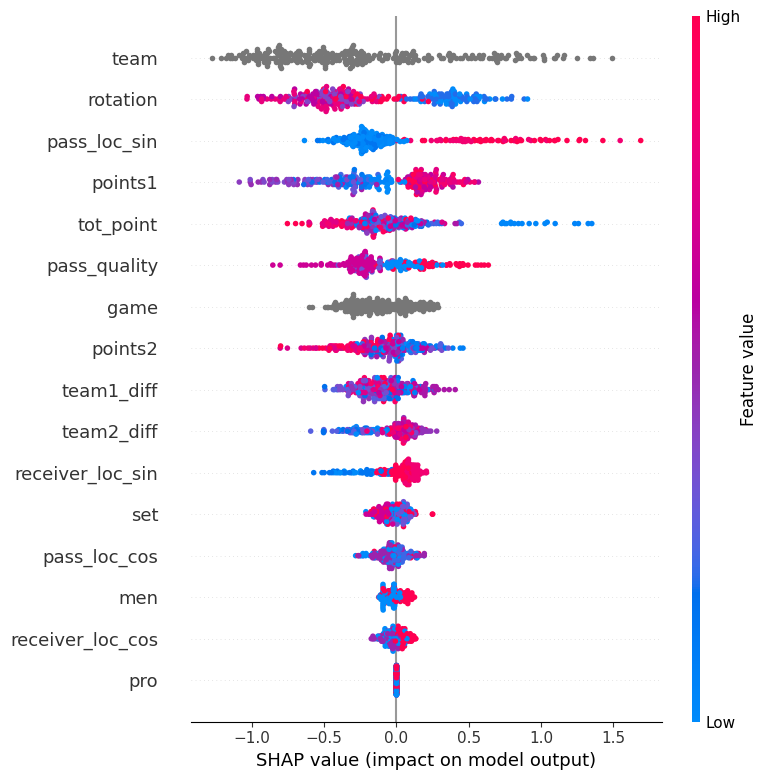

In [17]:
sv_class2 = sv.values[:, :, 2]   # shape (1366, 16)
shap.summary_plot(sv_class2, X_test_loc)

Team is the most influential.  3 sets are more likely when the setter is in the back row.  The further, the set is from the net, the more likely a 3 set is.  The point variables contradict each other.  Where 3s are more common when team 1 has many points, but less likely when both teams have many points and indistinguisable based on point differential.  The closer the first set is to the net, 3 is less likely. Level, gender, and lateral orientation of the first touch are the least important.

4 location

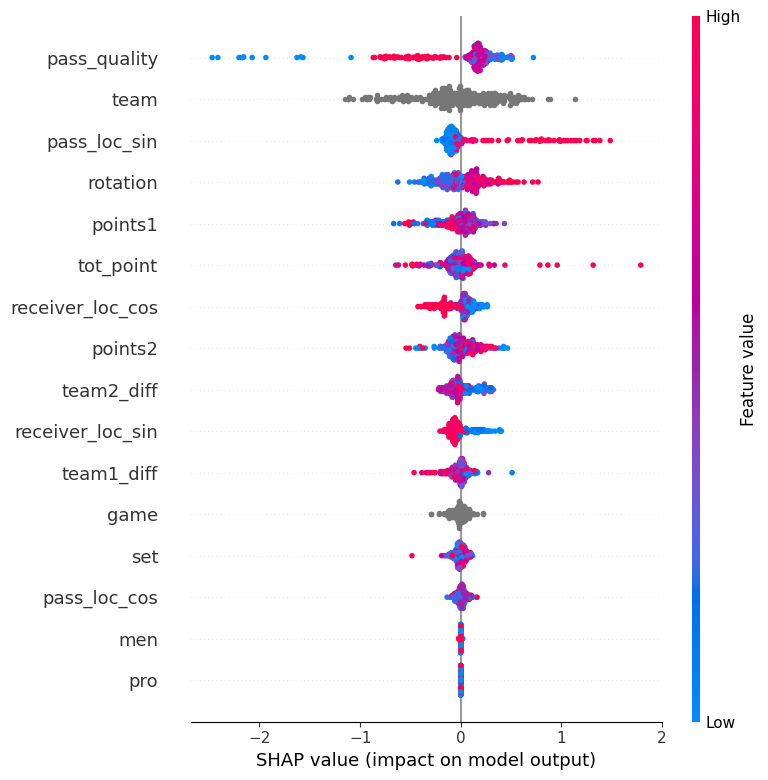

In [18]:
sv_class3 = sv.values[:, :, 3]   # shape (1366, 16)
shap.summary_plot(sv_class3, X_test_loc)

Pass quality, team, and rotation are the most influential variables, while level, gender, game stage(game,set_, and level are the least influential.  Low pass quality are less likely to be a 4 set.  When the setter is in the front row, a four set is more likely.  The further the second touch occurs from the net, the more likely the set is to be a four location.   As the set progresses, a 4 set becomes more likely.  The more left the first touch occurs, the less likely a four set is.   As the first touch gets closer to the net, the more likely a 4 set is.

5 Location

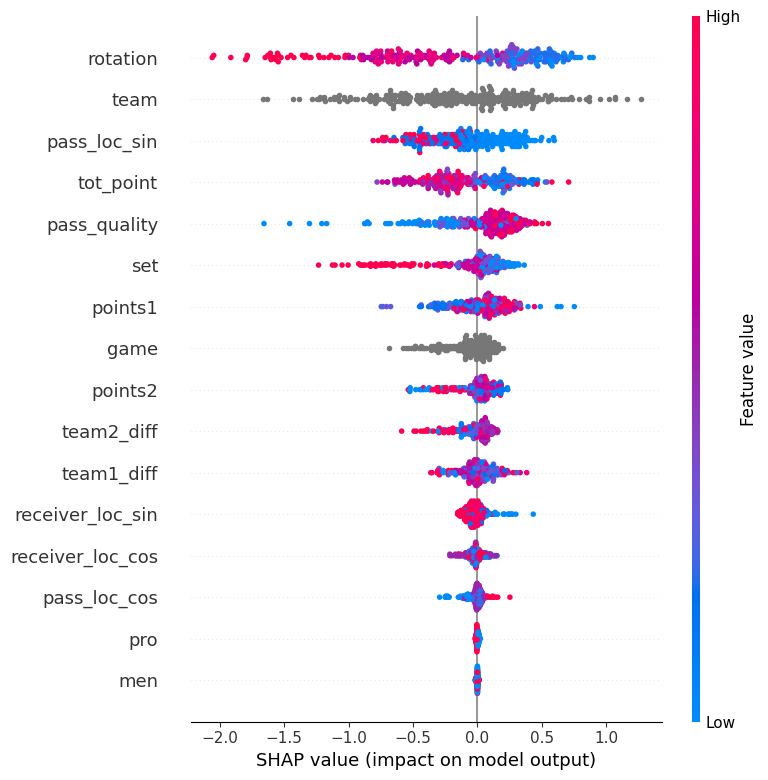

In [19]:
sv_class4 = sv.values[:, :, 4]   # shape (1366, 16)
shap.summary_plot(sv_class4, X_test_loc)

Rotation, team, how far the second touch occurs from the net, and the quality are the most influential variables.  The gender, level and right and left orientation of touches are the least importan.  When the right side hitter is in the back row, a 5 set is far lass likely.  The closer the second touch occurs to the net the more likely a 5 set is.  The lower the quality of the pass, the lower the likelihood of a 5 set is.  5 set are less likely in the early game(set low) but more frequent at the beginning of the set(low tot).  The closer the first touch occurs, the more likely a 5 set is.  The more right the second touch occurs, the less likely a 5 set is.

A location

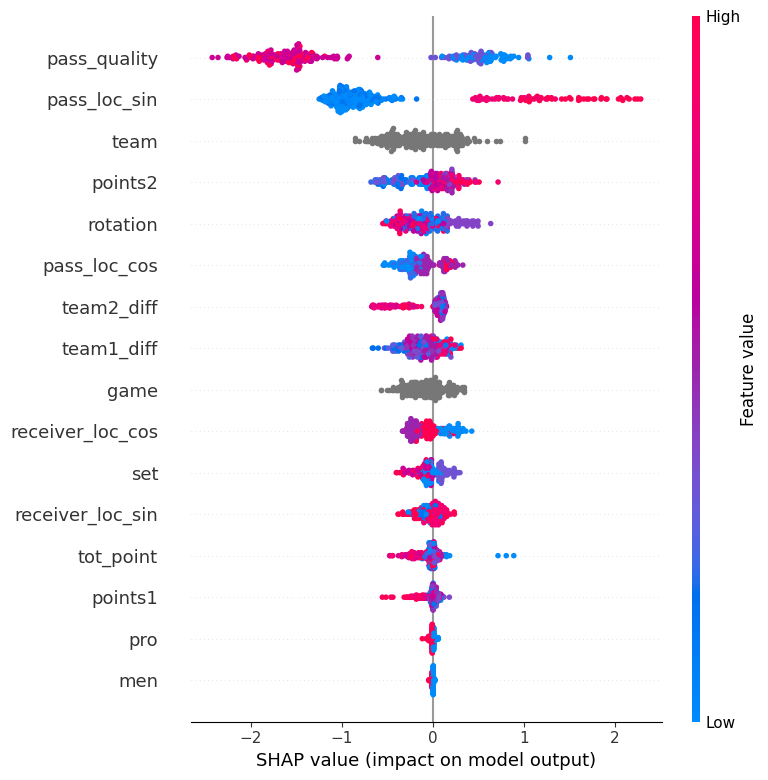

In [20]:
sv_class5 = sv.values[:, :, 5]   # shape (1366, 16)
shap.summary_plot(sv_class5, X_test_loc)

Pass quality, how far the second touch occurs from the net, and the team are the most influential variables, while the level and gender are the least.  First touch quality is inversely related to the likelihood of an A location set.  Similarly, the further the second touch is from the net, the more likely an A set is.  Sets on the right tend to not be A location sets.  The later the game is, the more likely an A set is.  When the first touch occurs on the right ride, an A set is less likely than from the middle.  

B location

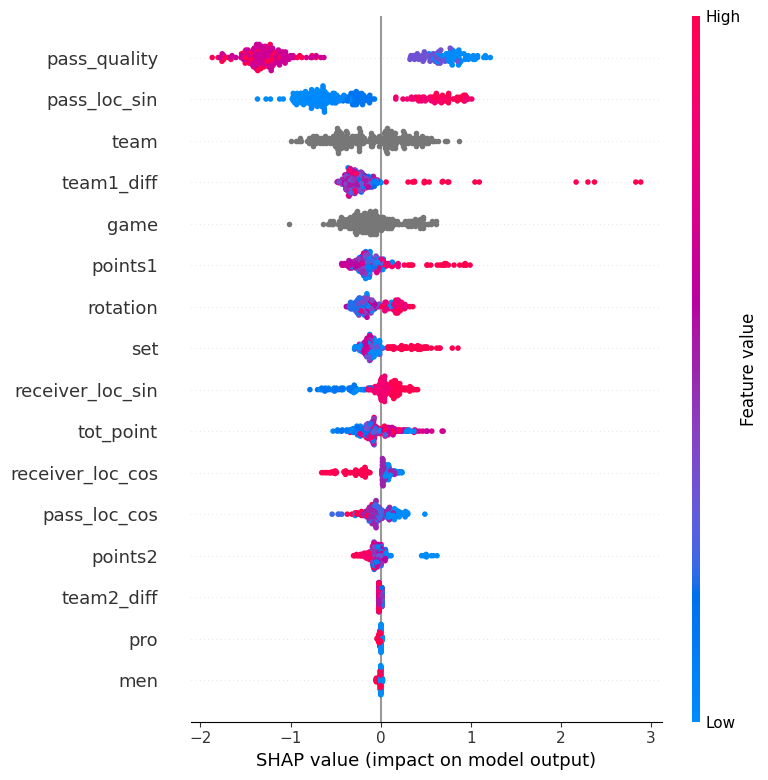

In [21]:
sv_class6 = sv.values[:, :, 6]   # shape (1366, 16)
shap.summary_plot(sv_class6, X_test_loc)

Pass quality, how far the second touch occurs from the net, point differential, and team are the most influential, while gander, level, and lateral location of touches are the least important.  Unsurprisingly similar to A.   First touch quality is inversely related to the likelihood of an A location set. Similarly, the further the second touch is from the net, the more likely a B set is.  As team 1 pulls ahead, the more likely a B set is.  As the first touch moves toward from the net, the less likely a B set becomes.  When the setter is in the back a B set is more likely.  Later in the game, a B set becomes more likely.  When the first touch is on the left, a B set is less likely.

C location

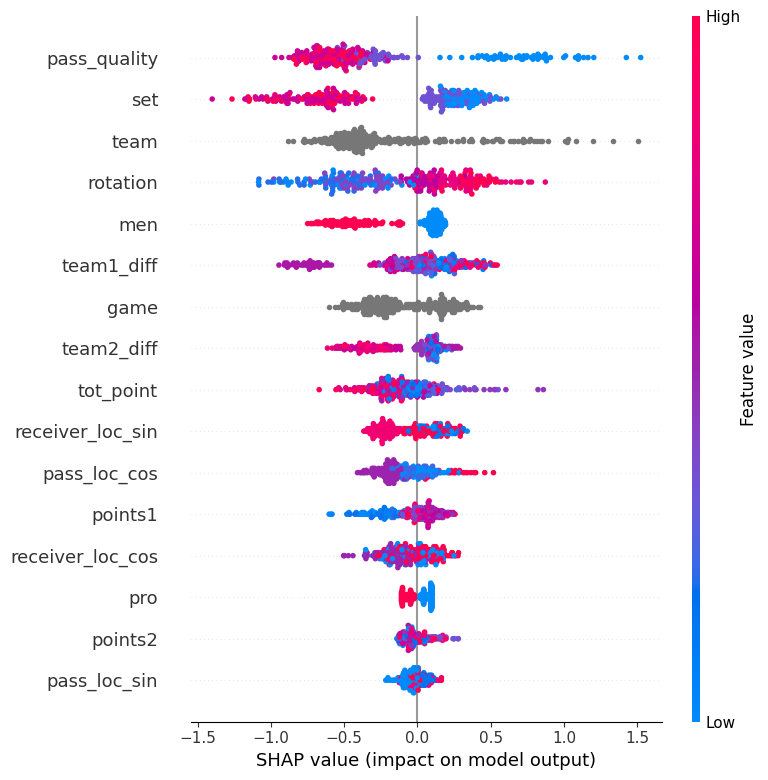

In [22]:
sv_class7 = sv.values[:, :, 7]   # shape (1366, 16)
shap.summary_plot(sv_class7, X_test_loc)

The most influential features are pass quality, set, and team, while the least influential are second touch from the net, level, and points.  Lesser passes are more likely to be C sets than high quality passes.  C sets are less likely in the late game.  C sets are more likely when the setter is in the front.  Men are less likely to set a C.  C sets are less frequent toward the end of a set.  When the pass is far from the net, a C set is less likely.  D1 are more likely to set C than professionals.  

D location

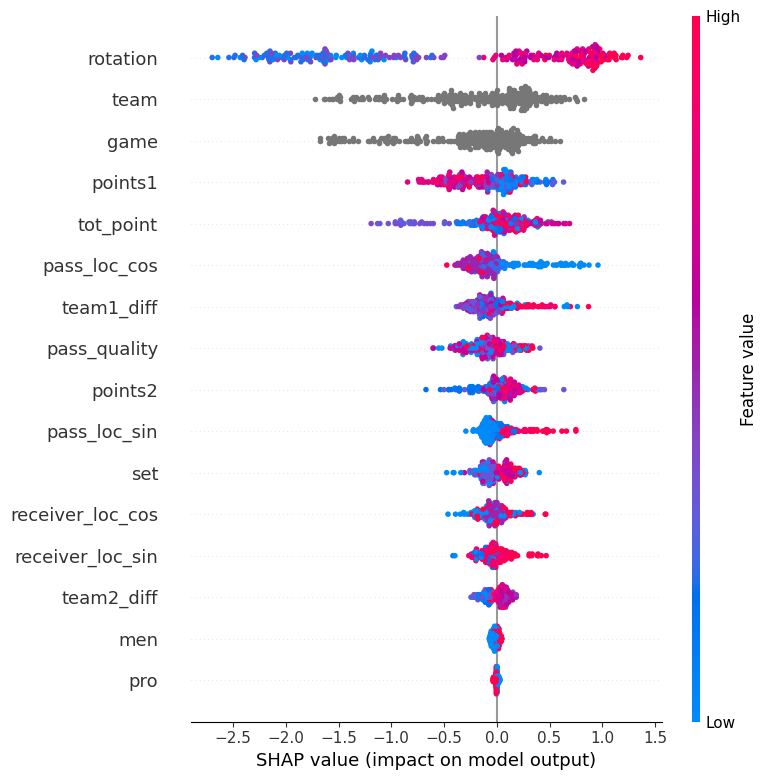

In [23]:
sv_class8 = sv.values[:, :, 8]   # shape (1366, 16)
shap.summary_plot(sv_class8, X_test_loc)

Rotation, team, and game are the most influential, while level, gender, and first touch location are the least.  When the setter is in the front row, a D set is far more likely.  When the set comes from the right side of the court, a D set is more likely.  When team 1 is winning, a D set is more likely.  When the set is further from the net, a D set is more likely.  When the receiver is far from the net, a D set is more likely.

Back 1 Location

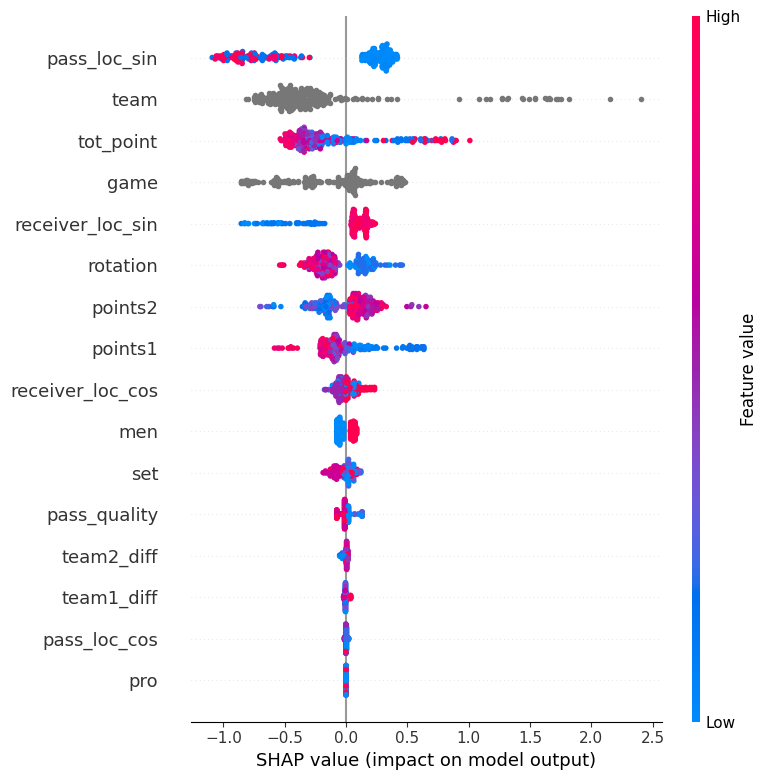

In [24]:
sv_class9 = sv.values[:, :, 9]   # shape (1366, 16)
shap.summary_plot(sv_class9, X_test_loc)

Team, second touch net distance, and total number of points are the most influential, while level, second touch horizontal orientation, point differential and pass quality are the least.  When the second touch is close to the net, a back 1 is more likely.  When the receiver is close, a back 1 is less likely.  When the setter is in the back row, a back 1 is more likely.  Men tend to set back 1s more.  

Back 3 Location

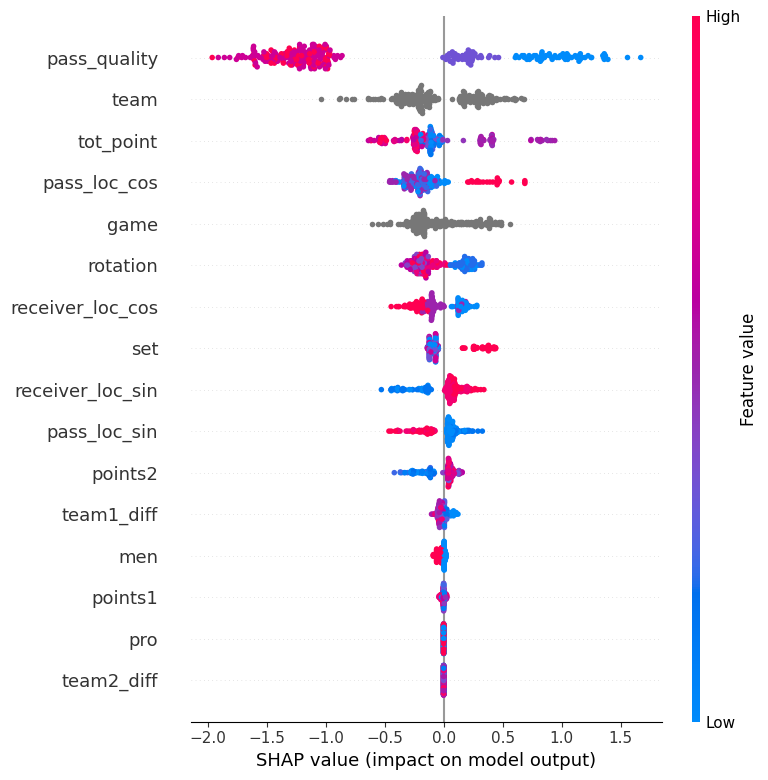

In [25]:
sv_class10 = sv.values[:, :, 10]   # shape (1366, 16)
shap.summary_plot(sv_class10, X_test_loc)

Pass quality, team and total point are the most influential, while level and gender are the least.  High pass qualities tend to not be back three sets.  At the end of the set, a back 3 is less likely than in the middle.  When the setter is in the back row, a bac 3 is more likely.  When the first touch occurs close to the net, a back 3 is less likely.  In the late game, a back 3 is more likely.  When the set is close to the net, a back 3 is more likely.   

Dump

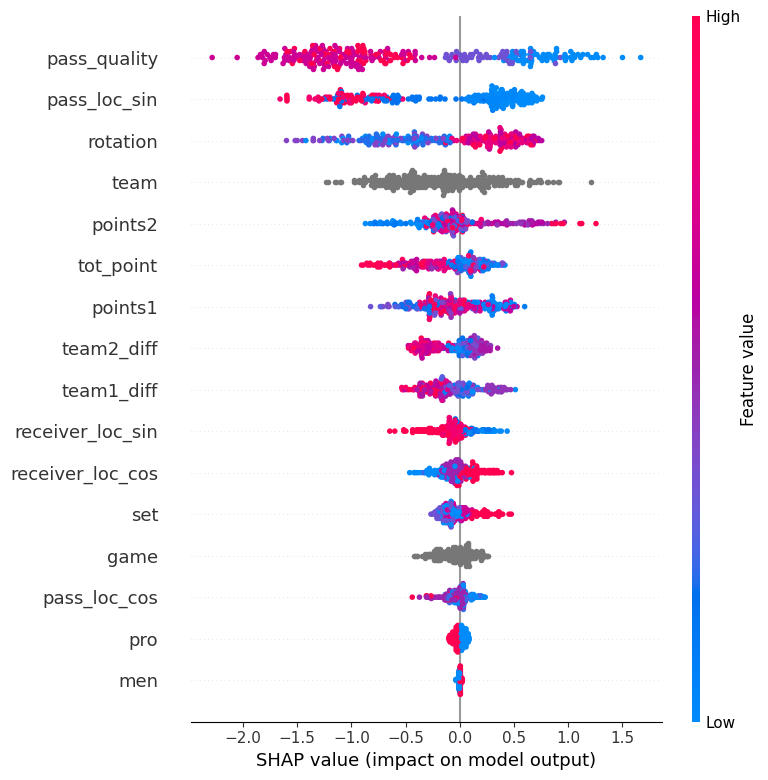

In [26]:
sv_class11 = sv.values[:, :, 11]   # shape (1366, 16)
shap.summary_plot(sv_class11, X_test_loc)

Pass quality, second touch distance, rotation, and team most influential, while gender, level, and lateral second touch orientation are the least.  When the first touch is high quality, a dump is far less likely.  A dump is more likely when the setter is in the front row.  When a second touch is far from the net, a dump is less likely.  Dumps are less likely in the late stages of a set but morel ikely in the late stage of a game.  Dumps are more likely in a close game.  When the first touch is further from the net, a dump is less likely.  As the first touch moves from left to right, a dump becomes less liekly.  Professionals tend to dump less.

Pipe Location

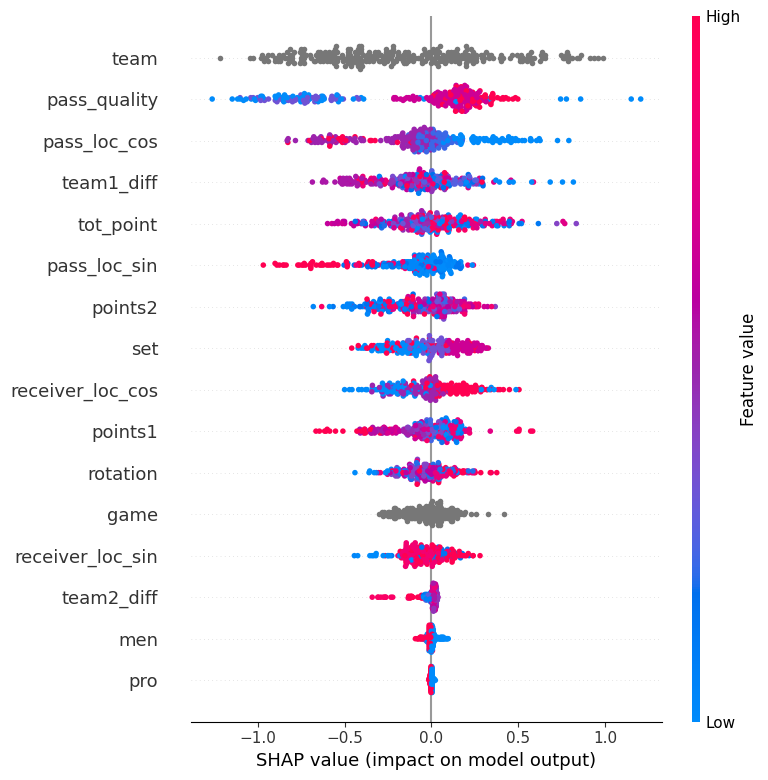

In [27]:
sv_class12 = sv.values[:, :, 12]   # shape (1366, 16)
shap.summary_plot(sv_class12, X_test_loc)

The most influential variables are pass quality, team, and lateral second touch location, while the least are level and gender.  The more right the second touch is, the more likely a pipe set is.  As the first touch location moves from right to left, a pipe set becomes less likely.  A pipe set is less likely when the second touch is futher from the net.  A pipe set is more likely when the setter is in the back row.

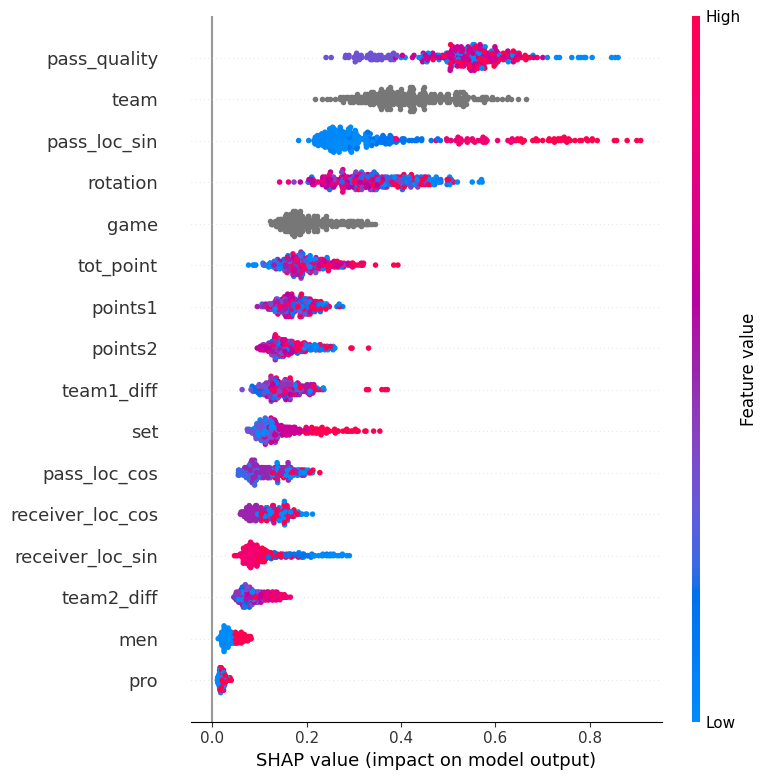

In [28]:
sv_global = np.abs(sv.values).mean(axis=2)   # shape (1366, 16)
shap.summary_plot(sv_global, X_test_loc)


Bad passes have the most impact(blue dots on the far right). Team is influential.  Second touch occuring further from the net is influential.  Total points especially, late game is influential.  Game is influential.

### 3e3. Test Performance

In [29]:
y_pred = best_model.predict(X_test_loc)
acc = accuracy_score(loc_test_enc, y_pred)
f1 = f1_score(loc_test_enc, y_pred, average = "macro")
print(f"Test accuracy: {acc}, Test F1 score: {f1}")
print("\nClassification Report")
print(classification_report(loc_test_enc,
                            y_pred,
                            target_names = le.classes_))

Test accuracy: 0.32081911262798635, Test F1 score: 0.15778931482372777

Classification Report
              precision    recall  f1-score   support

           1       0.12      0.07      0.09        27
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         7
           4       0.45      0.58      0.51       126
           5       0.14      0.19      0.16        32
           A       0.25      0.08      0.12        12
           B       0.00      0.00      0.00         7
           C       0.00      0.00      0.00         7
           D       0.24      0.30      0.27        27
       back1       0.00      0.00      0.00         6
       back3       1.00      0.50      0.67         2
        dump       0.33      0.10      0.15        10
        pipe       0.09      0.08      0.08        25

    accuracy                           0.32       293
   macro avg       0.20      0.15      0.16       293
weighted avg       0.28      0.32      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


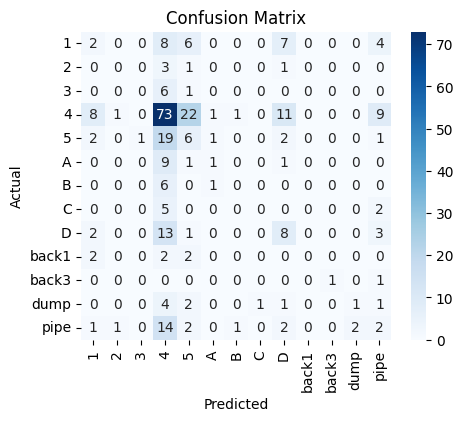

In [30]:
labels = le.classes_
plt.figure(figsize=(5,4))
cm = confusion_matrix(loc_test_enc, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels = labels, yticklabels = labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Compared to all other models, has the most prediction variation and decent accuracy with original set locations.  Explore groupings from original cnn.

# 7. Grouped Set Locations(orig cnn grouping)

##7a. Data

In [31]:
mapping = {
    # combine 2, back1, into 1
    "2": "1",
    "back1": "1",
    # combine 3, 4 into 4
    "3": "4",
    # back3 into 5
    "back3": "5",
    # combine A, B into left_back
    "A": "left_back",
    "B": "left_back",
    # combine C into D
    "C": "D"
}
def map_loc(x):
  return mapping.get(x,x)

for data in [df, train_df, val_df, test_df]:
  data['set_loc'] = [map_loc(x) for x in data["set_loc"]]

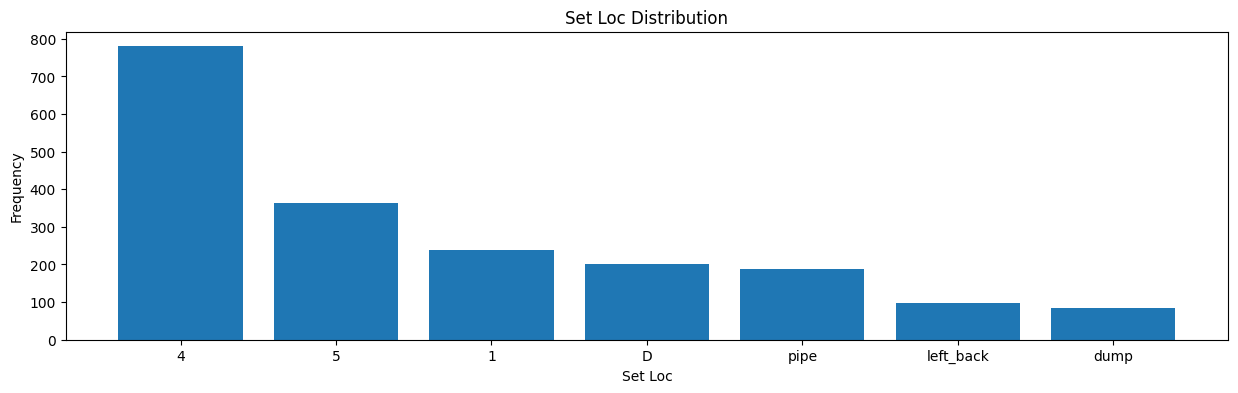

In [32]:
nums = df['set_loc'].value_counts()
fig, ax = plt.subplots(figsize = (15,4))
ax.bar(nums.index.astype(str), nums.values)
ax.set_xlabel("Set Loc")
ax.set_ylabel("Frequency")
ax.set_title("Set Loc Distribution")
plt.show()

In [33]:
loc_train = train_df['set_loc']
loc_train = loc_train.reset_index(drop=True)
loc_val = val_df['set_loc']
loc_val   = loc_val.reset_index(drop=True)
loc_test = test_df['set_loc']
loc_test  = loc_test.reset_index(drop=True)
classes = df['set_loc'].value_counts().index.tolist()
NUM_CLASS = len(df['set_loc'].value_counts().index.tolist())

##7b. Training

In [34]:
le = LabelEncoder()
le.fit(loc_train)
loc_train_enc = le.transform(loc_train)
loc_val_enc = le.transform(loc_val)
loc_test_enc = le.transform(loc_test)

In [35]:
DETERMINISTIC_ARGS = dict(
    enable_categorical=True,
    random_state=256,
    tree_method="hist",        # for repoduce
    n_jobs=1,                   # for reproduce
    sampling_method="uniform"   # for reproduce
)

In [36]:
loc_results = []
best_model = None
best_f1 = -1
print(f"Starting Grid Search on {len(experiments)} configurations...\n")
for i, conf in enumerate(experiments):
  model = XGBClassifier(**DETERMINISTIC_ARGS, **conf)
  model.fit(X_train_loc, loc_train_enc)
  y_pred = model.predict(X_val_loc)
  acc = accuracy_score(loc_val_enc, y_pred)
  f1 = f1_score(loc_val_enc, y_pred, average = "macro")
  res = conf.copy()
  res['index'] = i
  res['accuracy'] = acc
  res['f1'] = f1
  loc_results.append(res)
  print(f"Exp {i+1}:  LR = {conf['learning_rate']},  alpha = {conf['alpha']} ->  Val acc: {acc:.4f}, Val F1: {f1:.3f}")
  if f1 > best_f1:
    best_f1 = f1
    best_model = model

df_loc_results = pd.DataFrame(loc_results)
print("\n" + "="*40)
print(" Final Leaderboard by F1")
print("="*40)
# sort best to worst
print(df_loc_results.sort_values(by="f1", ascending = False).to_string(index=False))


Starting Grid Search on 5 configurations...

Exp 1:  LR = 0.1,  alpha = 1 ->  Val acc: 0.3242, Val F1: 0.214
Exp 2:  LR = 0.05,  alpha = 1 ->  Val acc: 0.3549, Val F1: 0.223
Exp 3:  LR = 0.2,  alpha = 1 ->  Val acc: 0.3925, Val F1: 0.217
Exp 4:  LR = 0.1,  alpha = 0.5 ->  Val acc: 0.3242, Val F1: 0.206
Exp 5:  LR = 0.1,  alpha = 5 ->  Val acc: 0.4027, Val F1: 0.228

 Final Leaderboard by F1
     objective  num_class  max_depth  learning_rate  n_estimators  alpha  index  accuracy       f1
multi:softprob         13          5           0.10           300    5.0      4  0.402730 0.228366
multi:softprob         13          4           0.05           400    1.0      1  0.354949 0.222769
multi:softprob         13          3           0.20            80    1.0      2  0.392491 0.217348
multi:softprob         13          4           0.10           300    1.0      0  0.324232 0.213660
multi:softprob         13          4           0.10           300    0.5      3  0.324232 0.205734


High alpha model performs best accross both metrics. Acc = 0.402730 F1 = 0.228366

## 7b1: Var Importance

####Gain

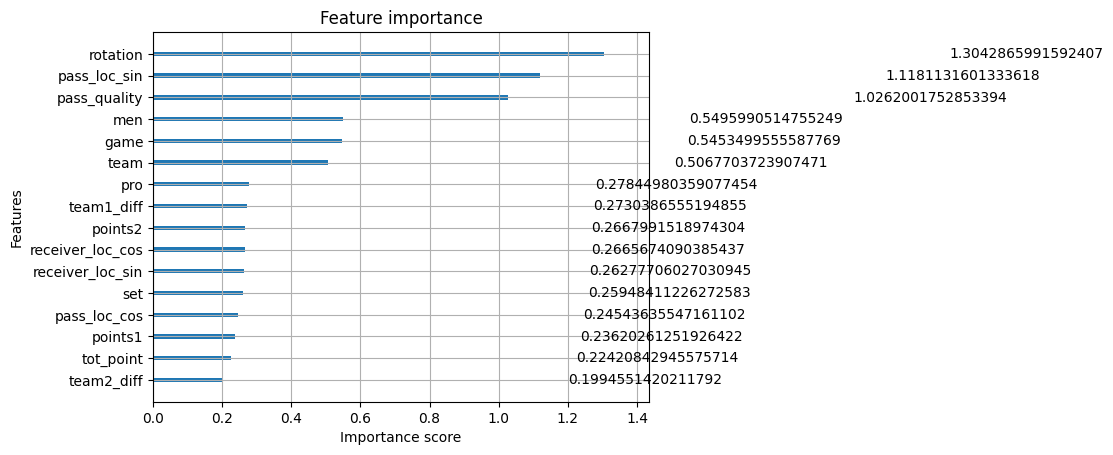

In [37]:
plot_importance(best_model, importance_type = 'gain')
plt.show()

Rotation and pass quality and distance are the most influential.  Points are the least after accounting.

#### Weight

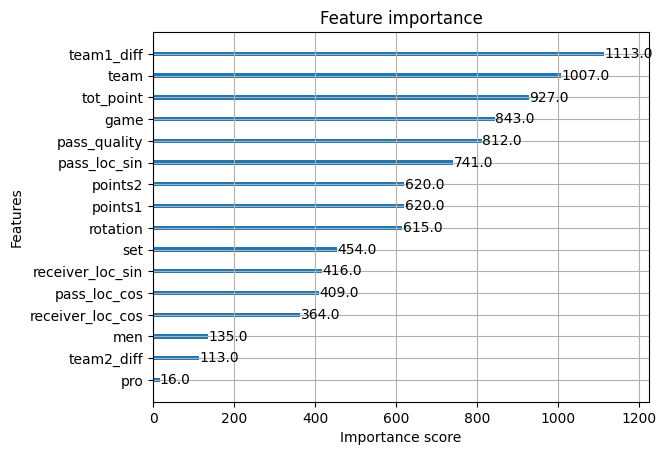

In [38]:
plot_importance(best_model, importance_type = 'weight')
plt.show()

Team, points, and game are most.  Level and gender are least

####Shap

In [41]:
explainer = shap.Explainer(best_model)
sv = explainer(X_test_loc)

print("sv shape:", sv.values.shape)
print("X_train_loc shape:", X_test_loc.shape)
print(le.classes_)

sv shape: (293, 16, 7)
X_train_loc shape: (293, 16)
['1' '4' '5' 'D' 'dump' 'left_back' 'pipe']


1 location

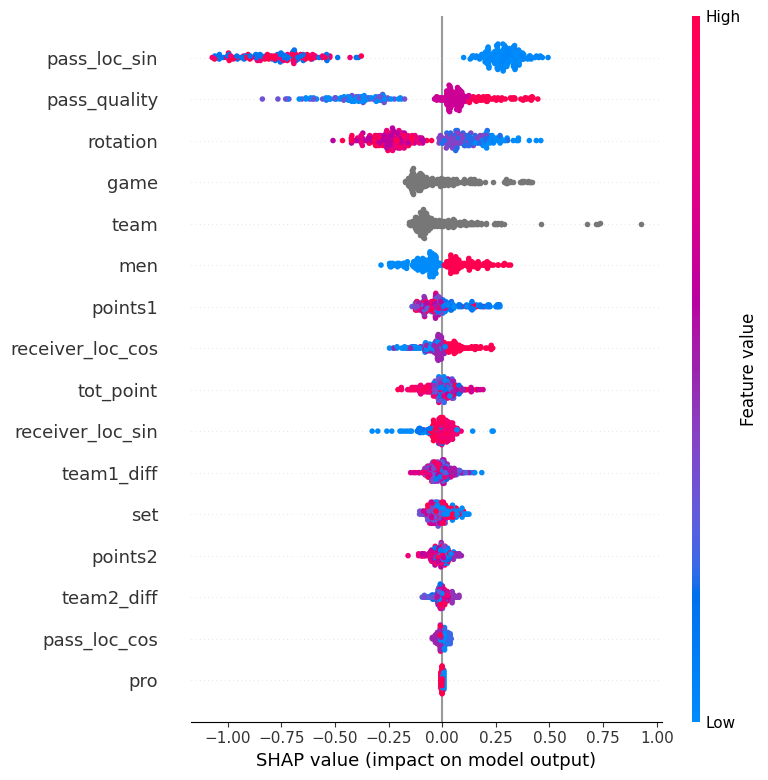

In [42]:
sv_class0 = sv.values[:, :, 0]   # shape (1366, 16)
shap.summary_plot(sv_class0, X_test_loc)

Team less and gender becomes more influential.  The point variables drop.  Relatively the same  Men tend to set 1s more than women.

4 Location

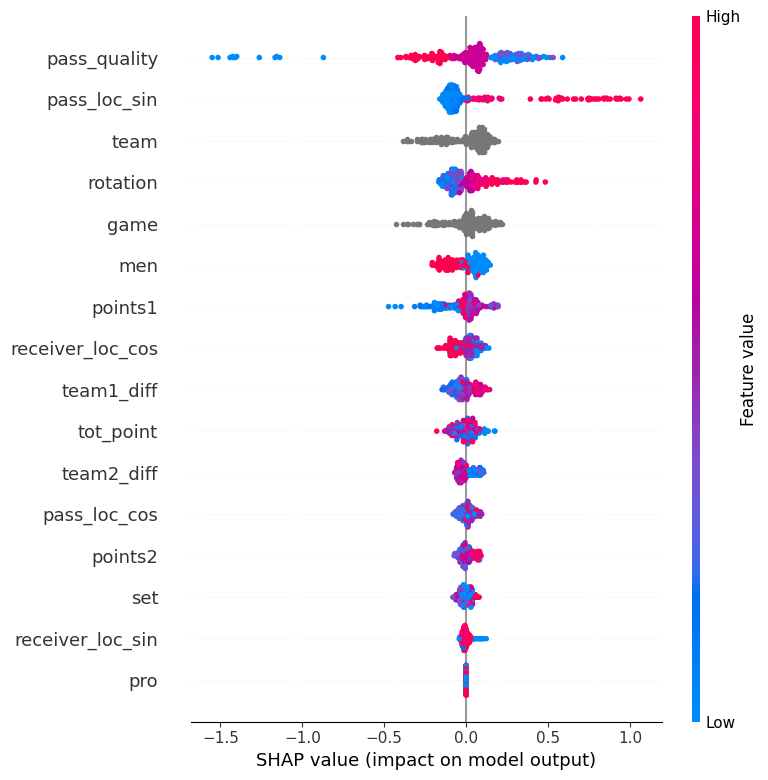

In [43]:
sv_class1 = sv.values[:, :, 1]   # shape (1366, 16)
shap.summary_plot(sv_class1, X_test_loc)

second touch dist becomes more important with the same relationship.  Total point drops in relevance.  Game increases in relevance.  Gender increases in relevance with women setting 4s more than men.  Relationships remain the same.

5 loc

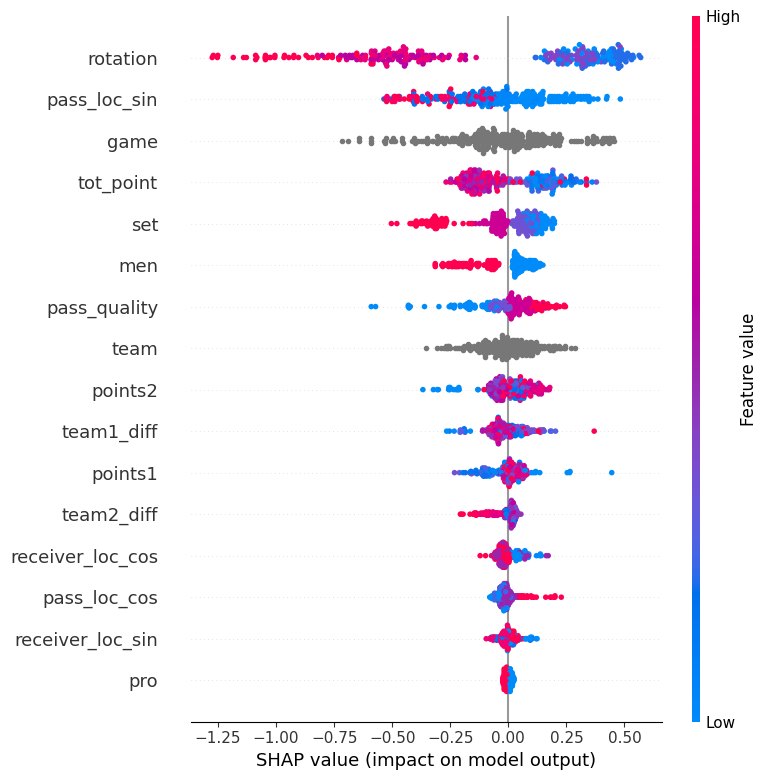

In [44]:
sv_class2 = sv.values[:, :, 2]   # shape (1366, 16)
shap.summary_plot(sv_class2, X_test_loc)

Team loses relevance, while game gains relevance.  Pass quality loses influence, while set and total points gain relevance.  Gendeer also increases in relevance with women setting 5s more than men.  Level and receiver loc are still not as influenctial.  

D loc

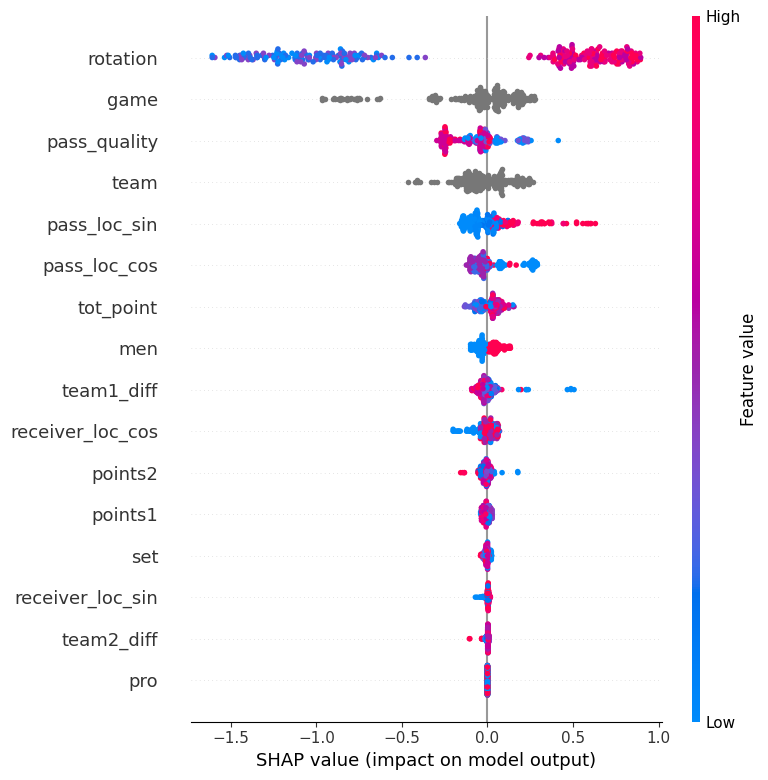

In [46]:
sv_class3 = sv.values[:, :, 3]   # shape (1366, 16)
shap.summary_plot(sv_class3, X_test_loc)

Rotaion remains the most infl.  Game and pass quality gain influence. High quality passes tend to not be D sets.  Team is still fairly relevant followed by pass location.  When the second touch is far from the net a D set is more likely.  Gender increases in influence with men setting a D ball more frequently.  

Dump loc

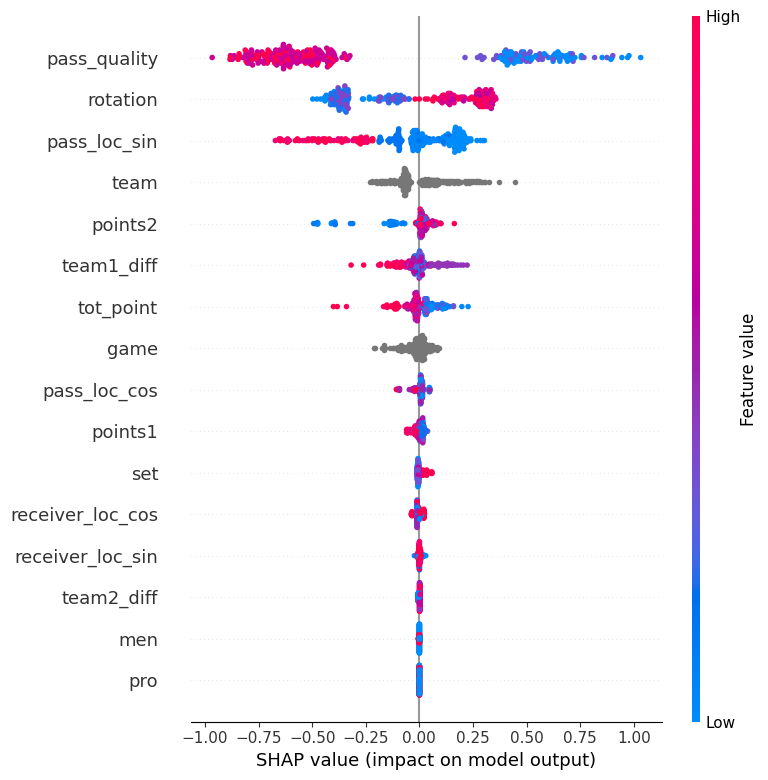

In [47]:
sv_class4 = sv.values[:, :, 4]   # shape (1366, 16)
shap.summary_plot(sv_class4, X_test_loc)

Rotation increases in relevance, but the other relevance and relationships remain fairly the same.

Left Loc

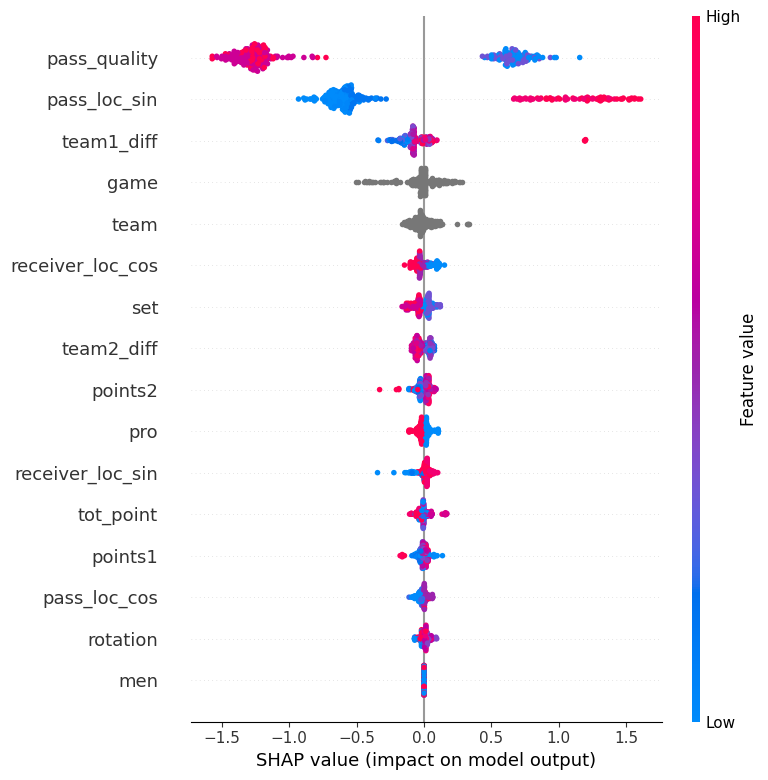

In [48]:
sv_class5 = sv.values[:, :, 5]   # shape (1366, 16)
shap.summary_plot(sv_class5, X_test_loc)

Pass quality and second touch net distance are still the most influential features, but gender and rotation are now the least influential features.  Team1's differential is now more prominent than the A location, so if team 1 is winning, they are more likely to set the back left.  Team and game mainain relevance.  Level gains some relevance with d1 players setting the left back more often.

Pipe

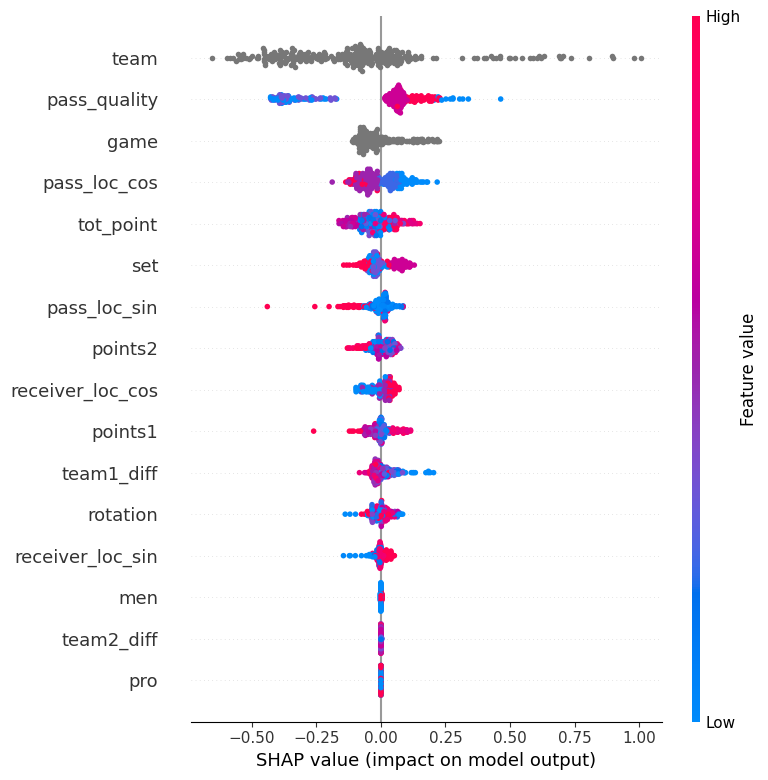

In [49]:
sv_class6 = sv.values[:, :, 6]   # shape (1366, 16)
shap.summary_plot(sv_class6, X_test_loc)

Team and pass quality stay the most important features, and game increases in relevance.  Team 1 diff drops in relevance, but most ordering and direction stays relatively the same.

Global

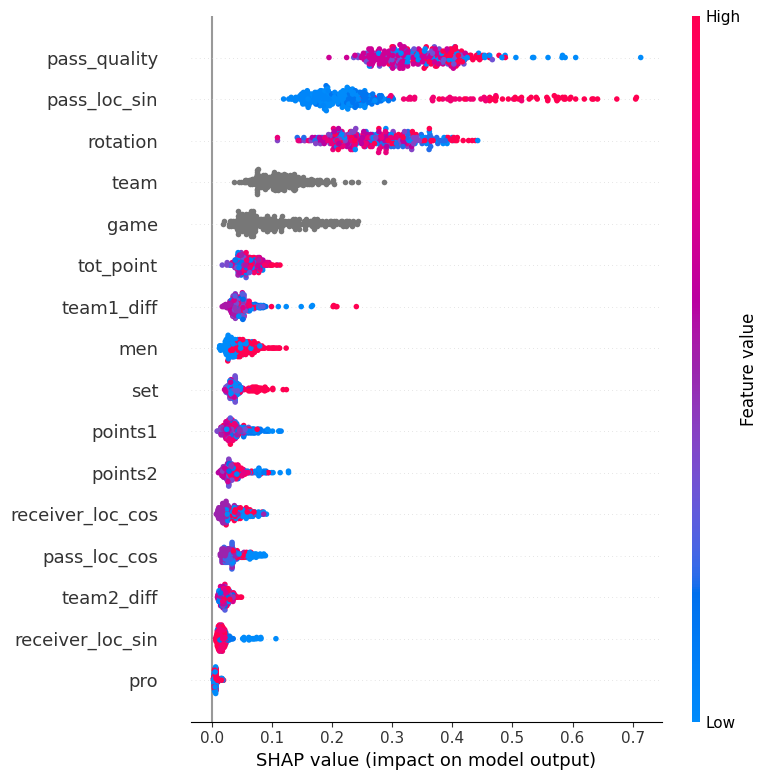

In [50]:
sv_global = np.abs(sv.values).mean(axis=2)   # shape (1366, 16)
shap.summary_plot(sv_global, X_test_loc)

Team drops in relevance, and gender increases in relevance.  second touch net distance also increases in relevance, pro remains the lowest.

## 7c. Test Performance

In [51]:
y_pred = best_model.predict(X_test_loc)
acc = accuracy_score(loc_test_enc, y_pred)
f1 = f1_score(loc_test_enc, y_pred, average = "macro")
print(f"Test accuracy: {acc}, Test F1 score: {f1}")
print("\nClassification Report")
print(classification_report(loc_test_enc,
                            y_pred,
                            target_names = le.classes_))

Test accuracy: 0.4129692832764505, Test F1 score: 0.20680467525906954

Classification Report
              precision    recall  f1-score   support

           1       0.24      0.13      0.17        38
           4       0.49      0.76      0.60       133
           5       0.17      0.18      0.17        34
           D       0.24      0.12      0.16        34
        dump       0.00      0.00      0.00        10
   left_back       0.33      0.16      0.21        19
        pipe       0.50      0.08      0.14        25

    accuracy                           0.41       293
   macro avg       0.28      0.20      0.21       293
weighted avg       0.37      0.41      0.36       293



Only one 0 f1 score compared to the 5 in the original model.  General increase in all metrics.  

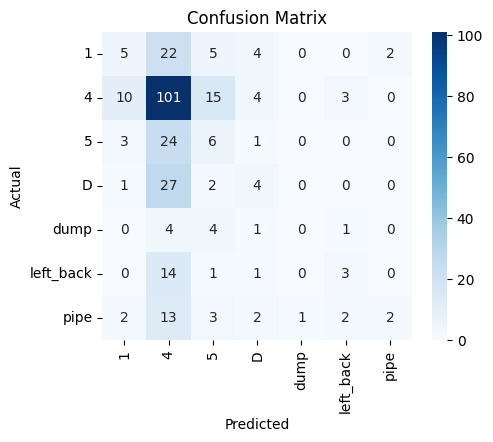

In [52]:
labels = le.classes_
plt.figure(figsize=(5,4))
cm = confusion_matrix(loc_test_enc, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels = labels, yticklabels = labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Slight performance increase with information loss, but more prediction variability with predictions in all classes, so retain with fewer categories.

## 7d. Feature selection

In [53]:
feature_importance = pd.DataFrame({
    "feature": X_test_loc.columns,
    "importance": np.abs(sv_global).mean(axis=0)
}).sort_values("importance", ascending=False)

print(feature_importance)

             feature  importance
8       pass_quality    0.352751
13      pass_loc_sin    0.276990
7           rotation    0.271961
9               team    0.115450
6               game    0.105489
4          tot_point    0.059821
2         team1_diff    0.052370
14               men    0.046607
5                set    0.044013
0            points1    0.039075
1            points2    0.038953
10  receiver_loc_cos    0.037950
12      pass_loc_cos    0.037156
3         team2_diff    0.021196
11  receiver_loc_sin    0.019288
15               pro    0.006176


1.   Using a 0.05 threshold, I will look at a model with pass_quality, rotation, pass_loc_sin, team, game, and total_points, and team1_diff.
2.   Based on columns, will investigate a the most relevant feature in group.  The chosen model includes pass_quality, rotation, team, tot_point.  The groups are first to second touch:[pass_quality, pass_loc, receiver_loc], dem:[team, game, men, pro], game stage: [tot_pt, team1, team2, point1/2, set], rotation.





### 7d1. 0.05 Threshhold

#### Data

In [54]:
X_train_loc = train_df[['pass_quality', 'rotation', 'pass_loc_sin', 'team', 'game', 'tot_point', 'team1_diff']]
loc_train = train_df['set_loc']
loc_train = loc_train.reset_index(drop=True)
X_val_loc = val_df[['pass_quality', 'rotation', 'pass_loc_sin', 'team', 'game', 'tot_point', 'team1_diff']]
loc_val = val_df['set_loc']
loc_val = loc_val.reset_index(drop=True)
X_test_loc = test_df[['pass_quality', 'rotation', 'pass_loc_sin', 'team', 'game', 'tot_point', 'team1_diff']]
loc_test = test_df['set_loc']
loc_test = loc_test.reset_index(drop=True)
classes = df['set_loc'].value_counts().index.tolist()
NUM_CLASS = len(df['set_loc'].value_counts().index.tolist())

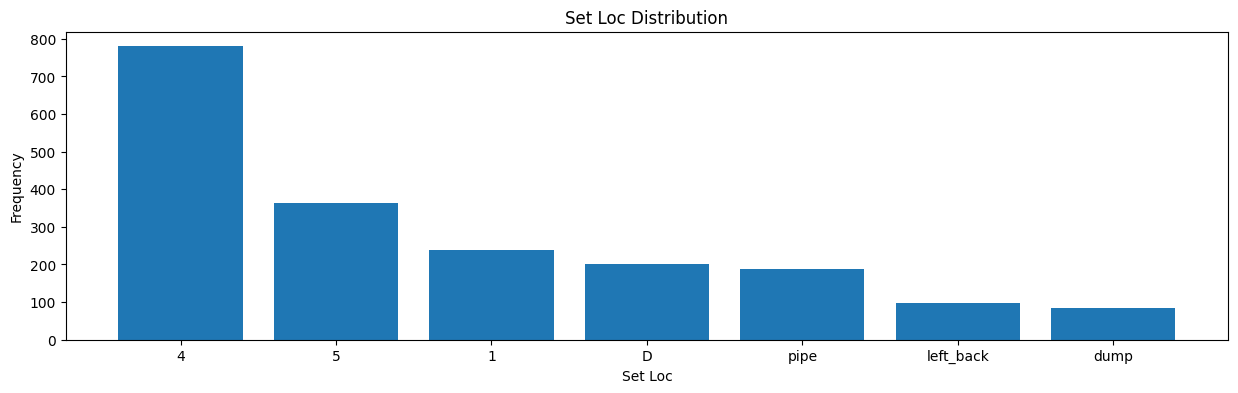

In [55]:
nums = df['set_loc'].value_counts()
fig, ax = plt.subplots(figsize = (15,4))
ax.bar(nums.index.astype(str), nums.values)
ax.set_xlabel("Set Loc")
ax.set_ylabel("Frequency")
ax.set_title("Set Loc Distribution")
plt.show()

####Model

In [56]:
loc_results = []
best_model = None
best_f1 = -1
print(f"Starting Grid Search on {len(experiments)} configurations...\n")
for i, conf in enumerate(experiments):
  model = XGBClassifier(**DETERMINISTIC_ARGS, **conf)
  model.fit(X_train_loc, loc_train_enc)
  y_pred = model.predict(X_val_loc)
  acc = accuracy_score(loc_val_enc, y_pred)
  f1 = f1_score(loc_val_enc, y_pred, average = "macro")
  res = conf.copy()
  res['index'] = i
  res['accuracy'] = acc
  res['f1'] = f1
  loc_results.append(res)
  print(f"Exp {i+1}:  LR = {conf['learning_rate']},  alpha = {conf['alpha']} ->  Val acc: {acc:.4f}, Val F1: {f1:.3f}")
  if f1 > best_f1:
    best_f1 = f1
    best_model = model

df_loc_results = pd.DataFrame(loc_results)
print("\n" + "="*40)
print(" Final Leaderboard by F1")
print("="*40)
# sort best to worst
print(df_loc_results.sort_values(by="f1", ascending = False).to_string(index=False))

Starting Grid Search on 5 configurations...

Exp 1:  LR = 0.1,  alpha = 1 ->  Val acc: 0.3959, Val F1: 0.232
Exp 2:  LR = 0.05,  alpha = 1 ->  Val acc: 0.3925, Val F1: 0.225
Exp 3:  LR = 0.2,  alpha = 1 ->  Val acc: 0.3993, Val F1: 0.208
Exp 4:  LR = 0.1,  alpha = 0.5 ->  Val acc: 0.3788, Val F1: 0.225
Exp 5:  LR = 0.1,  alpha = 5 ->  Val acc: 0.3857, Val F1: 0.178

 Final Leaderboard by F1
     objective  num_class  max_depth  learning_rate  n_estimators  alpha  index  accuracy       f1
multi:softprob         13          4           0.10           300    1.0      0  0.395904 0.232341
multi:softprob         13          4           0.05           400    1.0      1  0.392491 0.225468
multi:softprob         13          4           0.10           300    0.5      3  0.378840 0.224963
multi:softprob         13          3           0.20            80    1.0      2  0.399317 0.207627
multi:softprob         13          5           0.10           300    5.0      4  0.385666 0.178141


Best model is the baseline model with acc = 0.395904 and f1 = 0.232341, with the small learning rate close behind.  Similar performance(lower acc higher f1) with a simpler model.

#### Gain

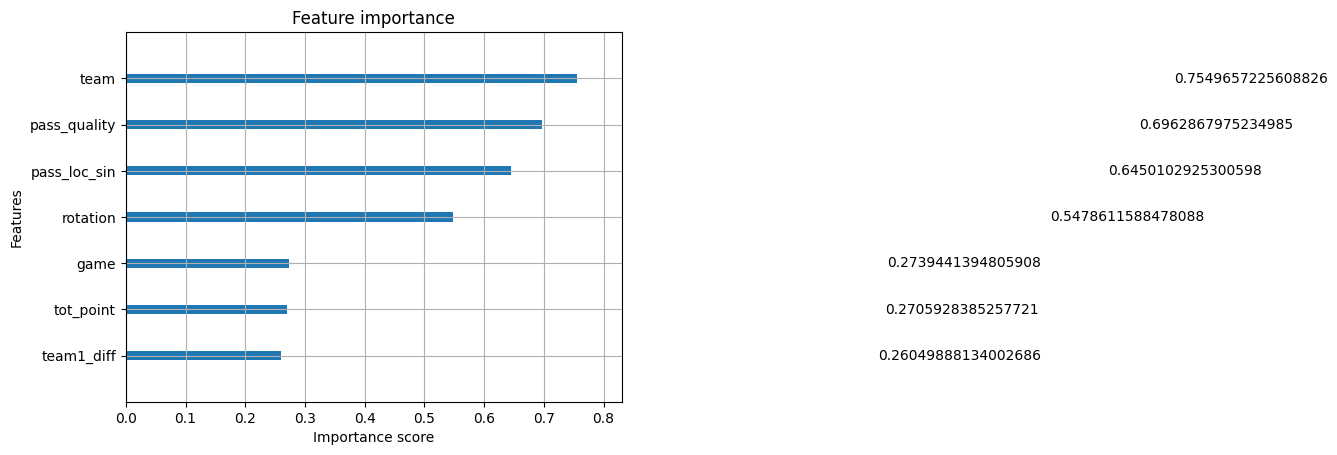

In [57]:
plot_importance(best_model, importance_type = 'gain')
plt.show()

Team is the most important followed by the pass quality vars, then rotation, game, then point vars.

#### Weight

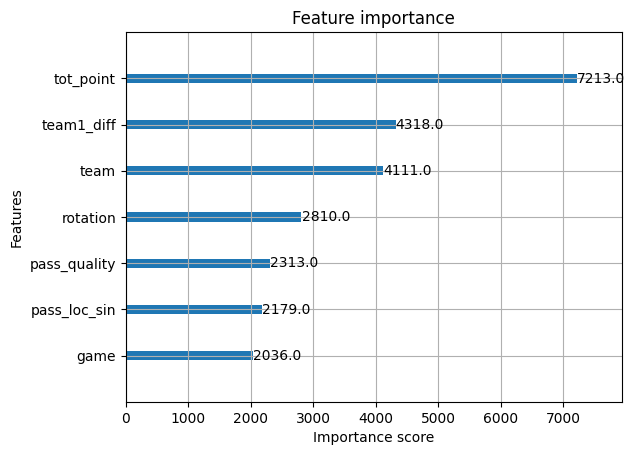

In [58]:
plot_importance(best_model, importance_type = 'weight')
plt.show()

Points most important now, with pass vars at the bottom with game.

#### Shap

In [60]:
explainer = shap.Explainer(best_model)
sv = explainer(X_test_loc)

print("sv shape:", sv.values.shape)
print("X_train_loc shape:", X_test_loc.shape)
print(le.classes_)

sv shape: (293, 7, 7)
X_train_loc shape: (293, 7)
['1' '4' '5' 'D' 'dump' 'left_back' 'pipe']


1 location

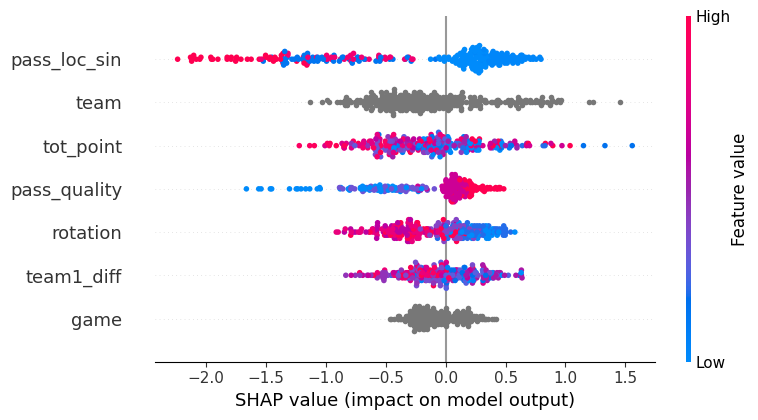

In [61]:
sv_class0 = sv.values[:, :, 0]   # shape (1366, 16)
shap.summary_plot(sv_class0, X_test_loc)

Slightly less separation than the original model(more noise), but similar directional relationships.  Second touch distance from the net is still the most influential, but game drops to the least influential where both point features were less influential before.  Team becomes the second most influential and rotation and pass quality drop.  

4 locaton

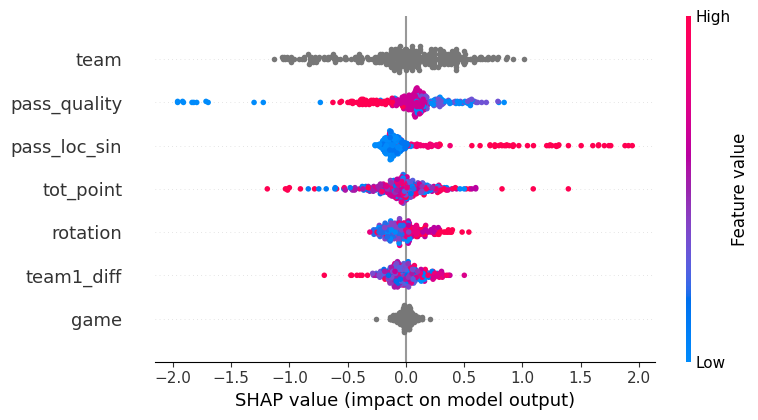

In [62]:
sv_class1 = sv.values[:, :, 1]   # shape (1366, 16)
shap.summary_plot(sv_class1, X_test_loc)

Similar to loc 1, there is more noise; howver, team1_diff has a more prominent association.  As team 1's point differential increases, the likelihood of a four set decreases.  The importance ordering changes with team being the most important passing pass quality and 2nd touch net distance.  Rotation falls one rank to total points which passes team1_diff as well, and game becomes the least important again.

5 location

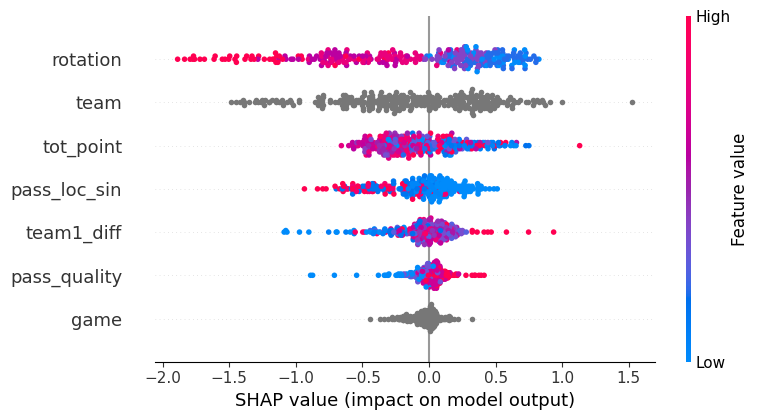

In [63]:
sv_class2 = sv.values[:, :, 2]   # shape (1366, 16)
shap.summary_plot(sv_class2, X_test_loc)

The total point relationship almost disappears, but the team1_diff direction becomes more prominent.  As team one goes from losing to winning, a 5 set is more likely.  Rotation remains the most important, and like the other locations, game is the least important.  Pass quality and 2nd touch dist fall in rank as well.

D loc

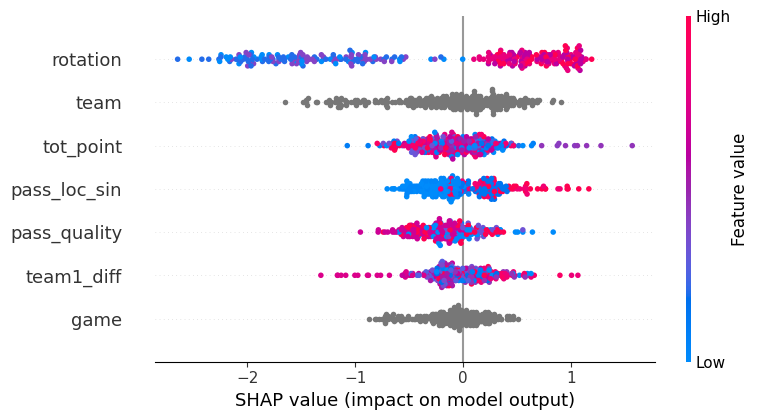

In [64]:
sv_class3 = sv.values[:, :, 3]   # shape (1366, 16)
shap.summary_plot(sv_class3, X_test_loc)

Game again falls to the least important, but rotation remains the top from th original model.  Pass quality falls as team and both point features rise.  

Dump loc

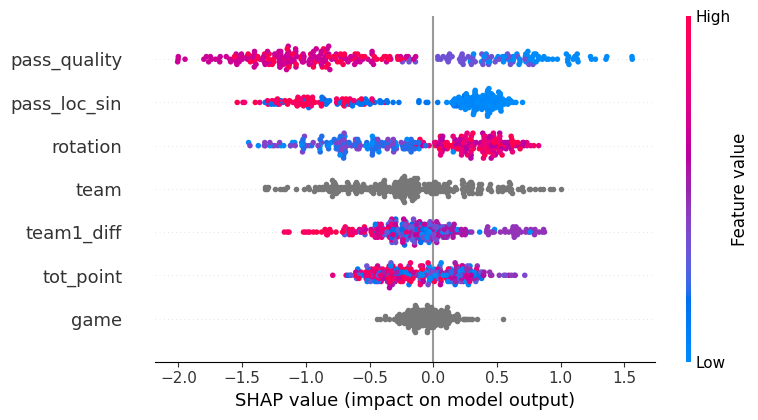

In [65]:
sv_class4 = sv.values[:, :, 4]   # shape (1366, 16)
shap.summary_plot(sv_class4, X_test_loc)

The ordering remains the same except for the two pass features.  The relationships stay the same.

Left Loc

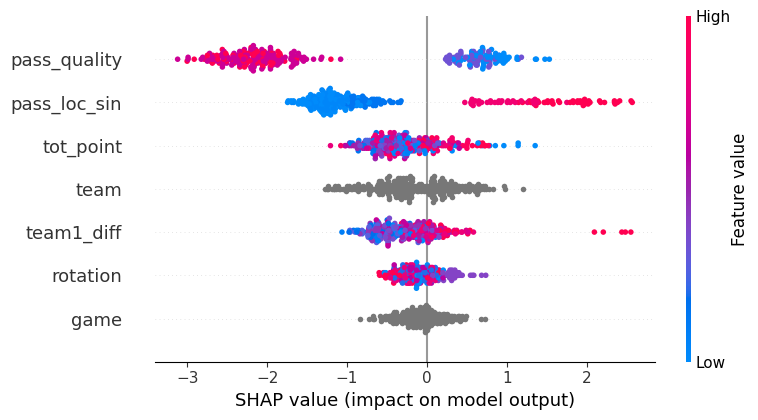

In [66]:
sv_class5 = sv.values[:, :, 5]   # shape (1366, 16)
shap.summary_plot(sv_class5, X_test_loc)

Total points beomes a more important feature, but the pass features are still more prominent.  game is the least prominent feature, but with rotation.  Point vars are in the middle with team.

Pipe loc

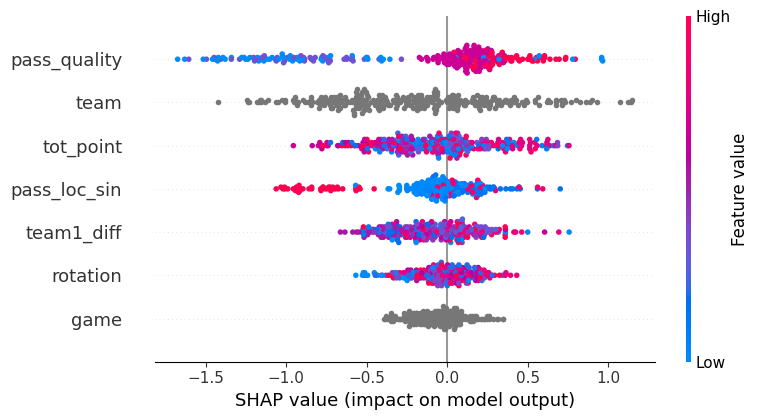

In [67]:
sv_class6 = sv.values[:, :, 6]   # shape (1366, 16)
shap.summary_plot(sv_class6, X_test_loc)

Team and pass quality are the most important.  Tot_point is the next most important as an increase.  Game is again at the bottom.

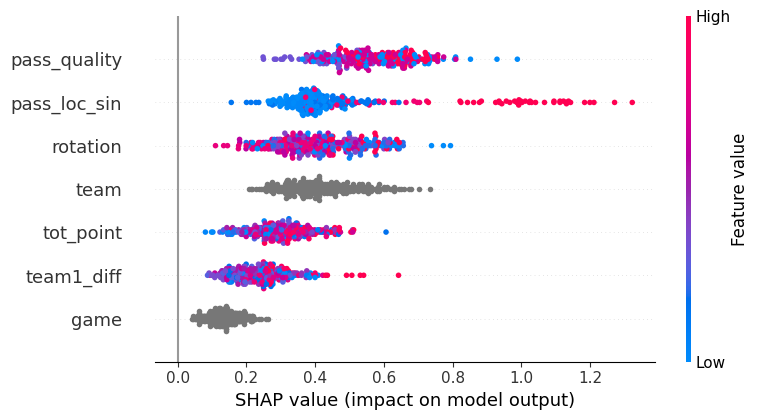

In [68]:
sv_global = np.abs(sv.values).mean(axis=2)   # shape (1366, 16)
shap.summary_plot(sv_global, X_test_loc)

Similar to acc increase plot, but game loses importance.  The diff features have different importance.

####Test performance

In [69]:
y_pred = best_model.predict(X_test_loc)
acc = accuracy_score(loc_test_enc, y_pred)
f1 = f1_score(loc_test_enc, y_pred, average = "macro")
print(f"Test accuracy: {acc}, Test F1 score: {f1}")
print("\nClassification Report")
print(classification_report(loc_test_enc,
                            y_pred,
                            target_names = le.classes_))

Test accuracy: 0.3993174061433447, Test F1 score: 0.22797824452511756

Classification Report
              precision    recall  f1-score   support

           1       0.33      0.18      0.24        38
           4       0.51      0.65      0.57       133
           5       0.23      0.32      0.27        34
           D       0.29      0.26      0.28        34
        dump       0.00      0.00      0.00        10
   left_back       0.20      0.11      0.14        19
        pipe       0.14      0.08      0.10        25

    accuracy                           0.40       293
   macro avg       0.24      0.23      0.23       293
weighted avg       0.36      0.40      0.37       293



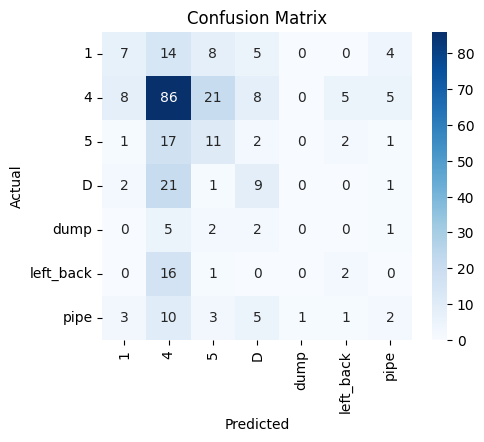

In [70]:
labels = le.classes_
plt.figure(figsize=(5,4))
cm = confusion_matrix(loc_test_enc, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels = labels, yticklabels = labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Similar to full model, but more prediction variation.

### 7d1. Group select

#### Data

In [71]:
X_train_loc = train_df[['pass_quality', 'rotation', 'team', 'tot_point']]
loc_train = train_df['set_loc']
loc_train = loc_train.reset_index(drop=True)
X_val_loc = val_df[['pass_quality', 'rotation', 'team', 'tot_point']]
loc_val = val_df['set_loc']
loc_val = loc_val.reset_index(drop=True)
X_test_loc = test_df[['pass_quality', 'rotation', 'team', 'tot_point']]
loc_test = test_df['set_loc']
loc_test = loc_test.reset_index(drop=True)
classes = df['set_loc'].value_counts().index.tolist()
NUM_CLASS = len(df['set_loc'].value_counts().index.tolist())

####Model

In [72]:
loc_results = []
best_model = None
best_f1 = -1
print(f"Starting Grid Search on {len(experiments)} configurations...\n")
for i, conf in enumerate(experiments):
  model = XGBClassifier(**DETERMINISTIC_ARGS, **conf)
  model.fit(X_train_loc, loc_train_enc)
  y_pred = model.predict(X_val_loc)
  acc = accuracy_score(loc_val_enc, y_pred)
  f1 = f1_score(loc_val_enc, y_pred, average = "macro")
  res = conf.copy()
  res['index'] = i
  res['accuracy'] = acc
  res['f1'] = f1
  loc_results.append(res)
  print(f"Exp {i+1}:  LR = {conf['learning_rate']},  alpha = {conf['alpha']} ->  Val acc: {acc:.4f}, Val F1: {f1:.3f}")
  if f1 > best_f1:
    best_f1 = f1
    best_model = model

df_loc_results = pd.DataFrame(loc_results)
print("\n" + "="*40)
print(" Final Leaderboard by F1")
print("="*40)
# sort best to worst
print(df_loc_results.sort_values(by="f1", ascending = False).to_string(index=False))

Starting Grid Search on 5 configurations...

Exp 1:  LR = 0.1,  alpha = 1 ->  Val acc: 0.3891, Val F1: 0.222
Exp 2:  LR = 0.05,  alpha = 1 ->  Val acc: 0.3857, Val F1: 0.207
Exp 3:  LR = 0.2,  alpha = 1 ->  Val acc: 0.3993, Val F1: 0.202
Exp 4:  LR = 0.1,  alpha = 0.5 ->  Val acc: 0.3857, Val F1: 0.230
Exp 5:  LR = 0.1,  alpha = 5 ->  Val acc: 0.4130, Val F1: 0.183

 Final Leaderboard by F1
     objective  num_class  max_depth  learning_rate  n_estimators  alpha  index  accuracy       f1
multi:softprob         13          4           0.10           300    0.5      3  0.385666 0.229506
multi:softprob         13          4           0.10           300    1.0      0  0.389078 0.222326
multi:softprob         13          4           0.05           400    1.0      1  0.385666 0.207235
multi:softprob         13          3           0.20            80    1.0      2  0.399317 0.201609
multi:softprob         13          5           0.10           300    5.0      4  0.412969 0.183197


Low alpha model performs the best. Acc = 0.385666 ad f1 = 0.229506, slight acc drop and slight f1 inc from orig model, and drop in both to other reduced model, so retain other reduced model with 7 features.